In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from autopep8 import join_logical_line

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('heart.csv')

In [3]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [4]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [5]:
df.size

11016

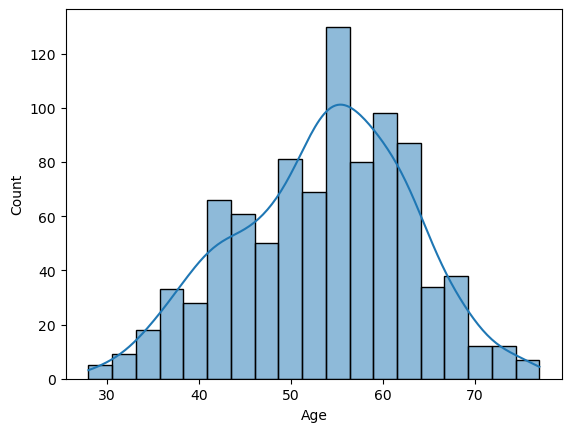

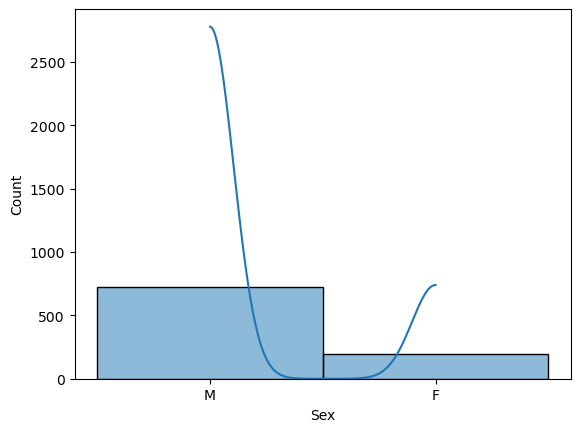

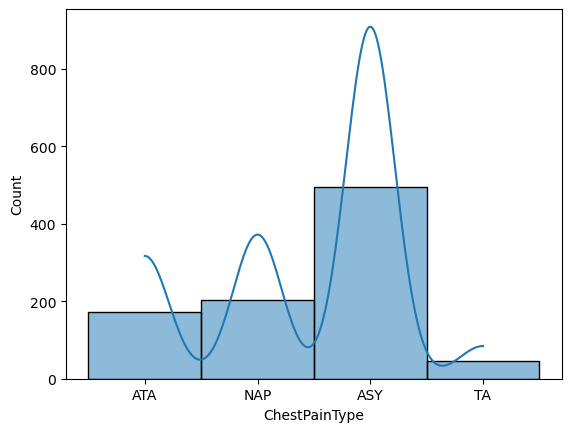

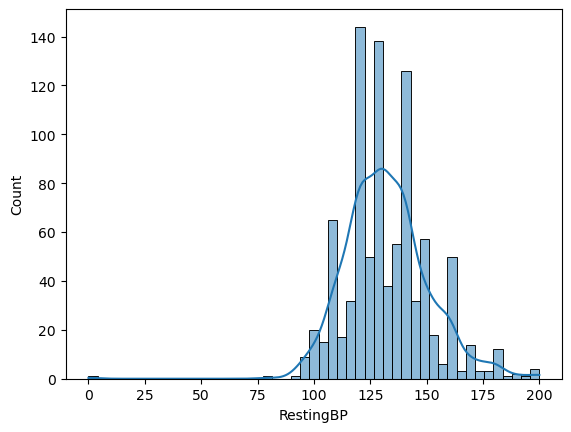

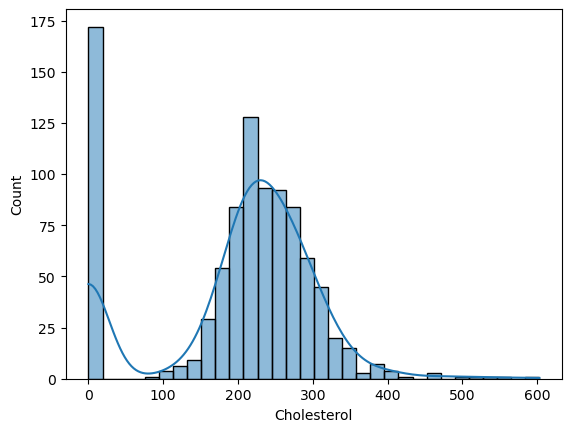

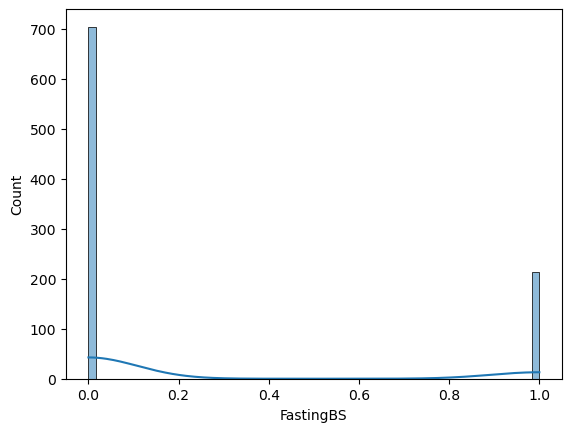

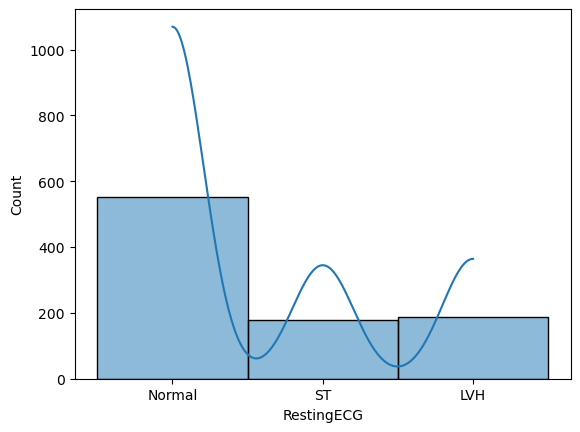

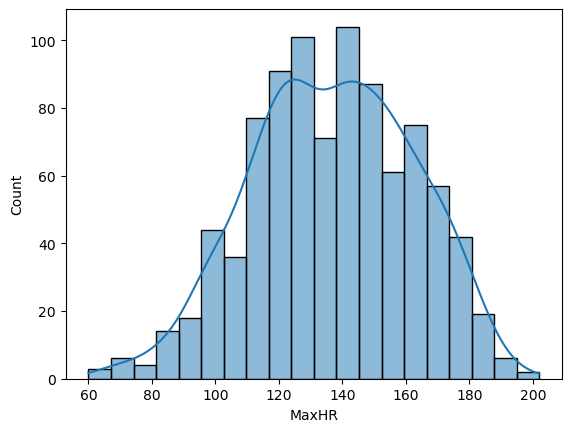

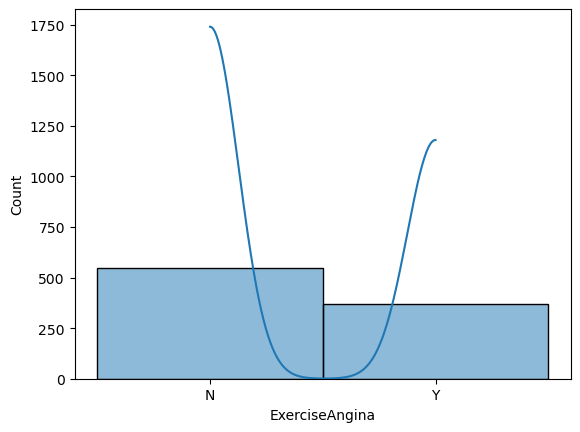

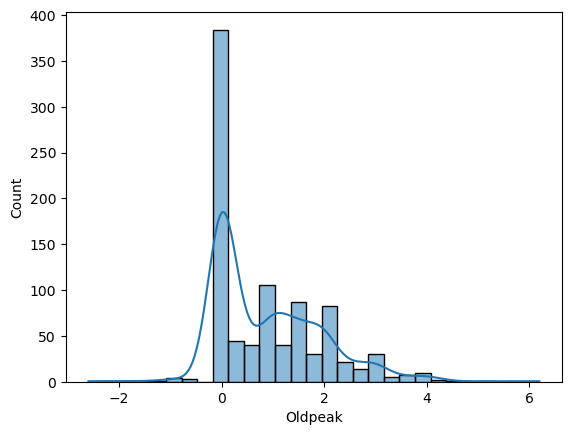

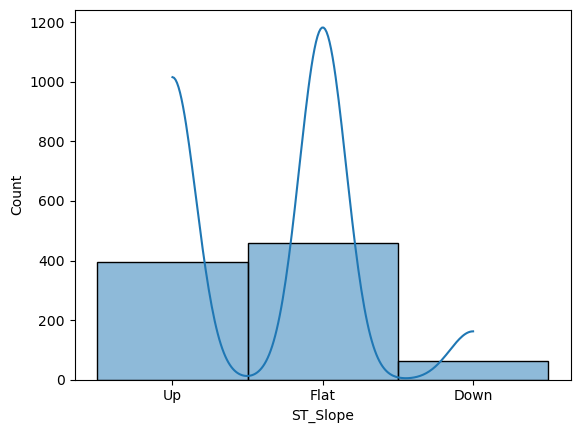

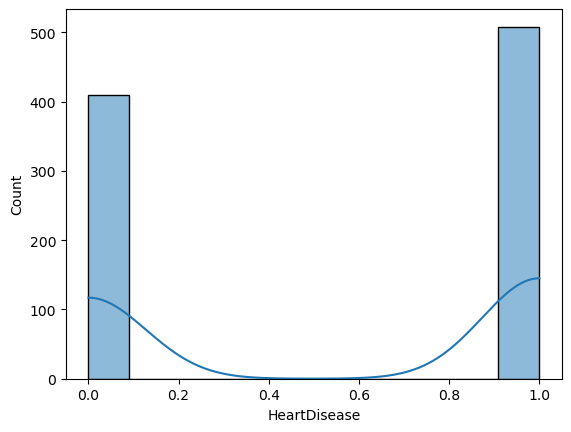

In [6]:
def plot(col):
    plt.figure()
    sns.histplot(df[col], kde=True)

colums = ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease']

for col in colums:
    plot(col)

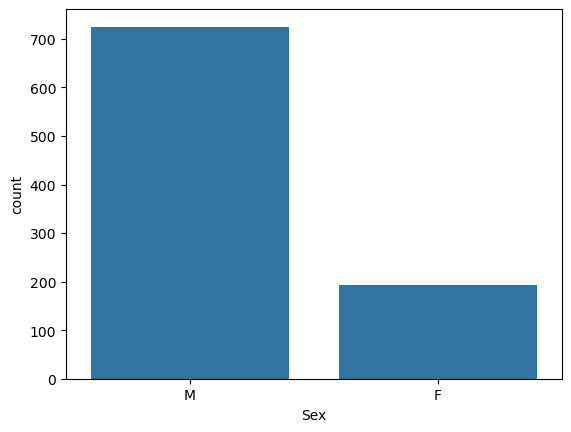

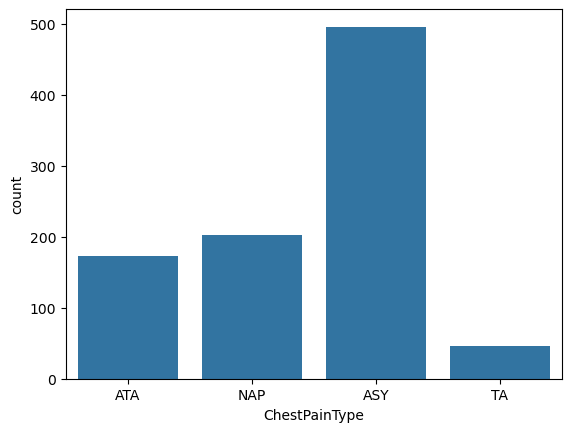

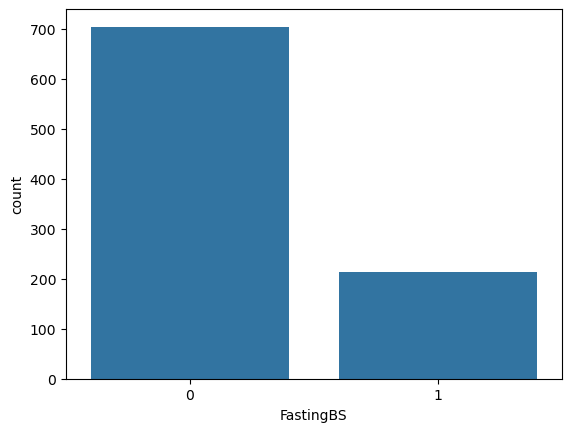

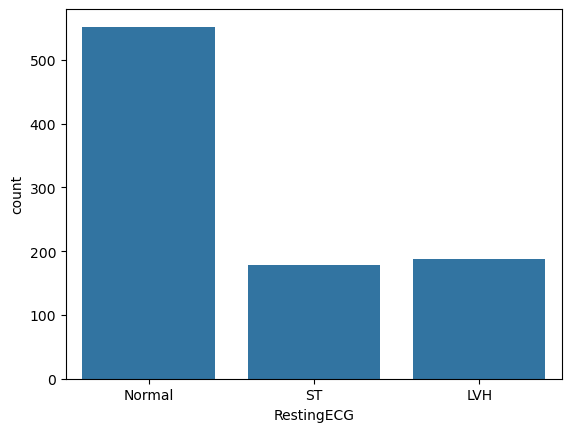

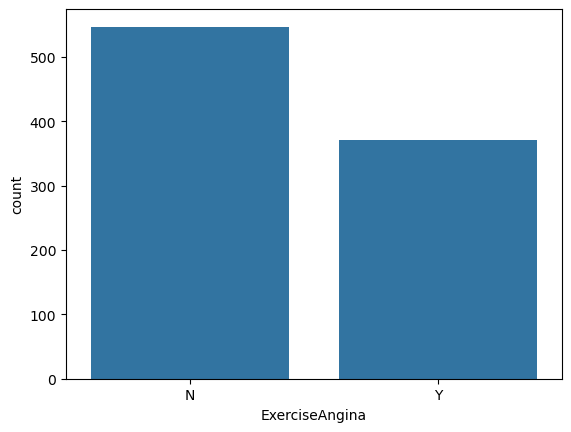

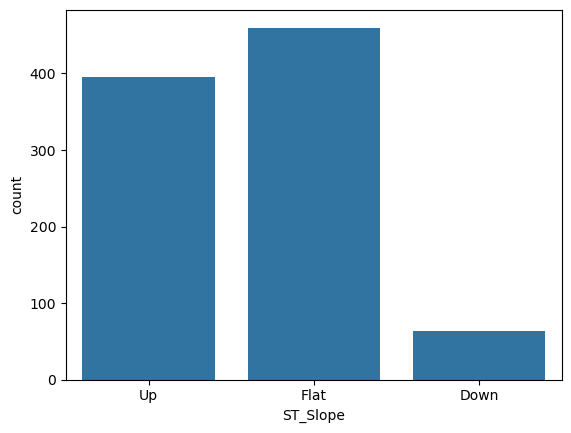

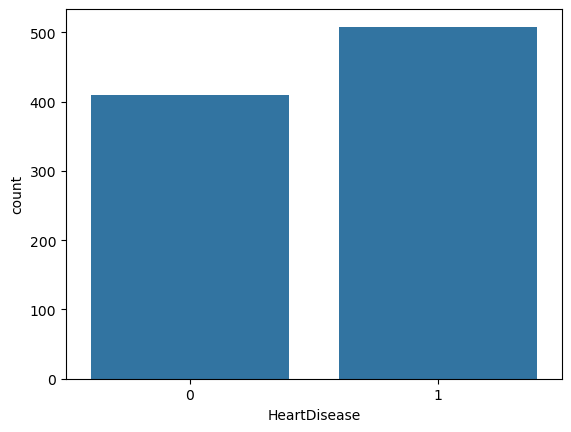

In [7]:
cat_columns = ['Sex', 'ChestPainType', 'FastingBS',
       'RestingECG', 'ExerciseAngina', 'ST_Slope',
       'HeartDisease']

for col in cat_columns:
    plt.figure()
    sns.countplot(x=df[col])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [9]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['HeartDisease'].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

In [12]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [13]:
df['RestingBP'].value_counts()

RestingBP
120    132
130    118
140    107
110     58
150     55
      ... 
185      1
98       1
92       1
113      1
164      1
Name: count, Length: 67, dtype: int64

In [14]:
ch_mean = df.loc[df['Cholesterol'] != 0, 'Cholesterol'].mean()

In [15]:
ch_mean

np.float64(244.6353887399464)

In [16]:
df['Cholesterol'] = df['Cholesterol'].replace(0, ch_mean)

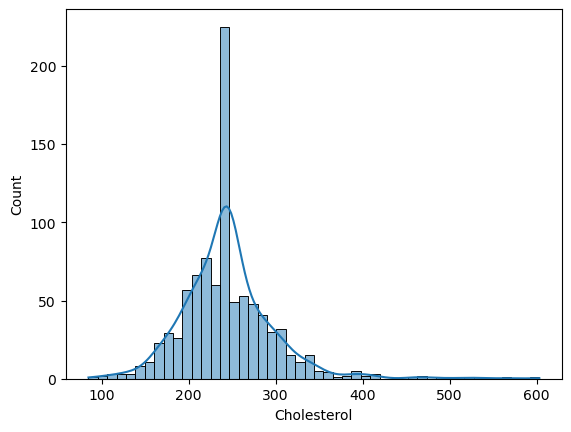

In [17]:
plot('Cholesterol')

In [18]:
rbp_mean = df.loc[df['RestingBP'] != 0, 'RestingBP'].mean()

In [19]:
df['RestingBP'] = df['RestingBP'].replace(0, rbp_mean)

In [20]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

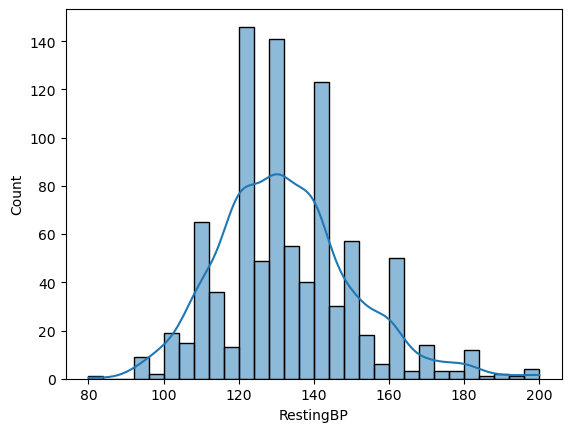

In [21]:
plot('RestingBP')

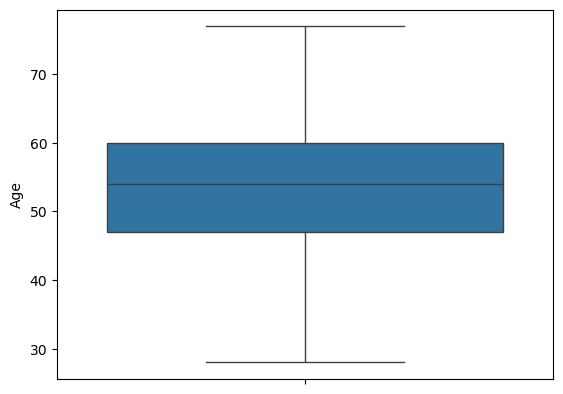

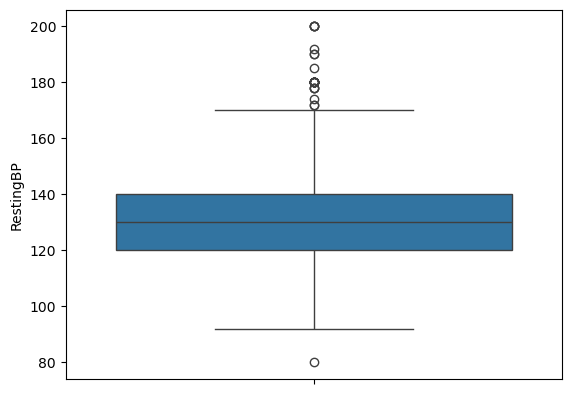

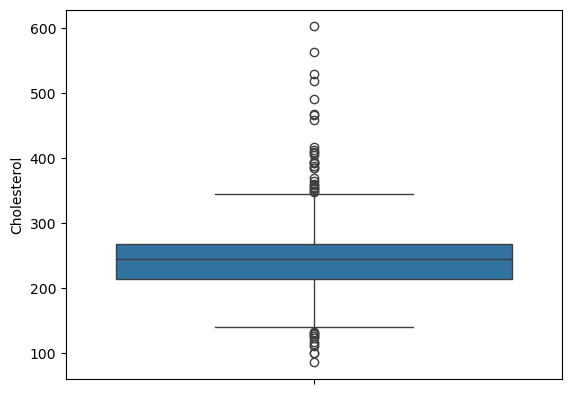

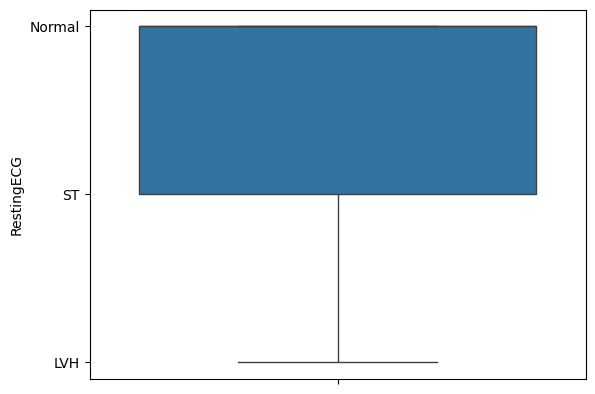

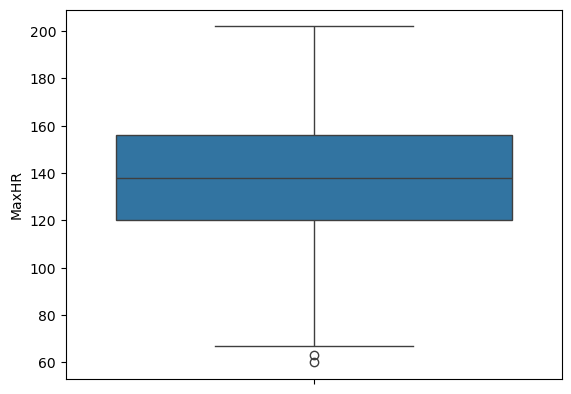

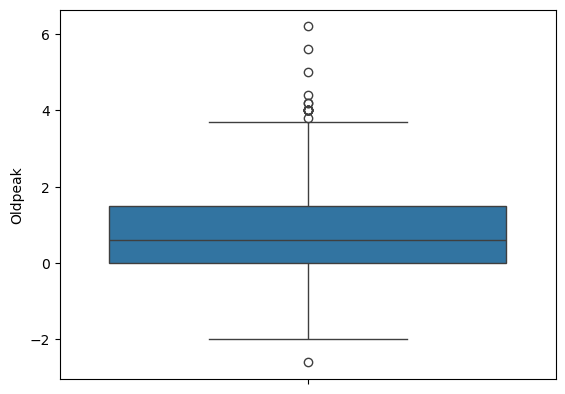

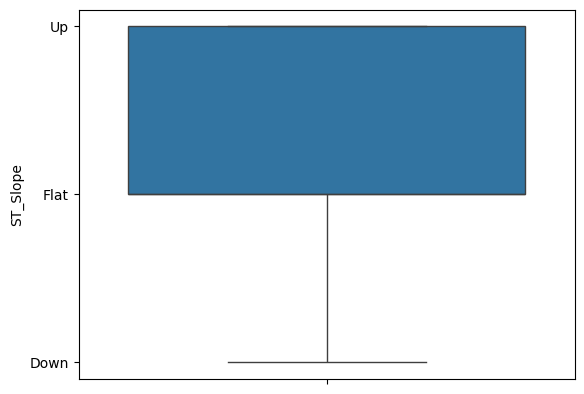

In [22]:
num_columns = ['Age', 'RestingBP', 'Cholesterol',
       'RestingECG', 'MaxHR', 'Oldpeak', 'ST_Slope',]


for col in num_columns:
    plt.figure()
    sns.boxplot(df[col])

<Axes: >

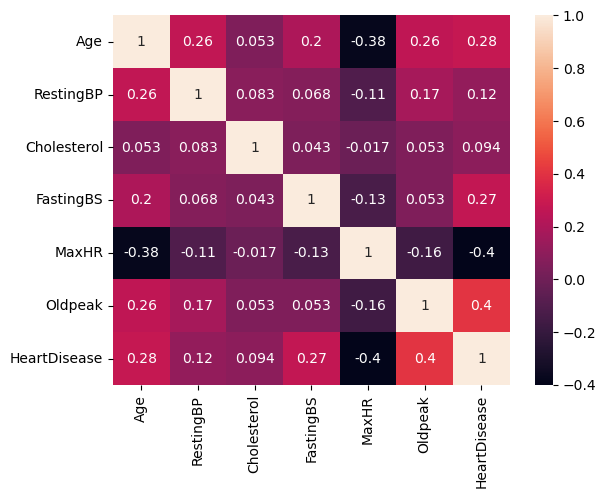

In [23]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [24]:
df_encode_0 = pd.get_dummies(df)

In [25]:
df_encode_0

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138.0,214.0,0,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150.0,195.0,0,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110.0,264.0,0,132,1.2,1,False,True,False,...,False,True,False,True,False,True,False,False,True,False
914,68,144.0,193.0,1,141,3.4,1,False,True,True,...,False,False,False,True,False,True,False,False,True,False
915,57,130.0,131.0,0,115,1.2,1,False,True,True,...,False,False,False,True,False,False,True,False,True,False
916,57,130.0,236.0,0,174,0.0,1,True,False,False,...,False,False,True,False,False,True,False,False,True,False


In [26]:
df_encode = df_encode_0

In [27]:
df_encode.drop(columns='Sex_F', inplace=True)

In [28]:
df_encode = df_encode.astype(int)

In [29]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,0,1,0,0,0,1,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,0,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,0,1,0,0,0,0,1,1,0,0,0,1
3,48,138,214,0,108,1,1,0,1,0,0,0,0,1,0,0,1,0,1,0
4,54,150,195,0,122,0,0,1,0,0,1,0,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,1,0,0,0,1,0,1,0,1,0,0,1,0
914,68,144,193,1,141,3,1,1,1,0,0,0,0,1,0,1,0,0,1,0
915,57,130,131,0,115,1,1,1,1,0,0,0,0,1,0,0,1,0,1,0
916,57,130,236,0,174,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0


<Axes: >

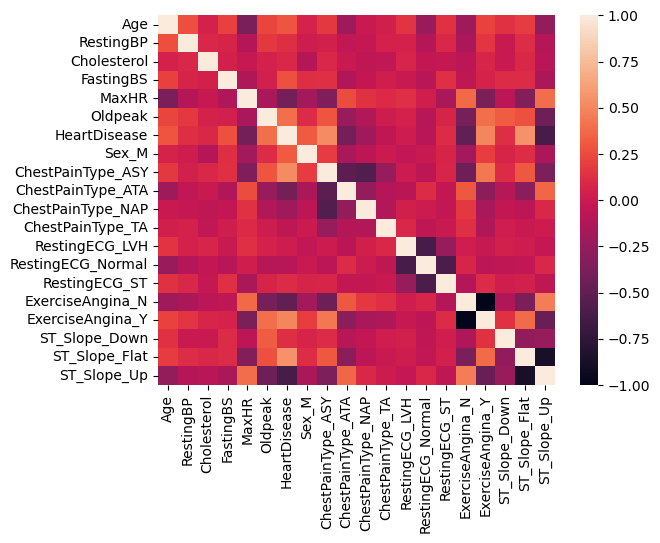

In [30]:
sns.heatmap(df_encode.corr(numeric_only=True))

In [31]:
from sklearn.preprocessing import StandardScaler
scale_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
scalar = StandardScaler()
df_encode[scale_cols] = scalar.fit_transform(df_encode[scale_cols])

In [32]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414885,0.834754,0,1.382928,-0.727592,0,1,0,1,0,0,0,1,0,1,0,0,0,1
1,-0.478484,1.527224,-1.210675,0,0.754157,0.282891,1,0,0,0,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141284,0.722161,0,-1.525138,-0.727592,0,1,0,1,0,0,0,0,1,1,0,0,0,1
3,-0.584556,0.303651,-0.572651,0,-1.132156,0.282891,1,0,1,0,0,0,0,1,0,0,1,0,1,0
4,0.051881,0.971054,-0.929194,0,-0.581981,-0.727592,0,1,0,0,1,0,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,-0.902775,-1.253622,0.365619,0,-0.188999,0.282891,1,1,0,0,0,1,0,1,0,1,0,0,1,0
914,1.536902,0.637353,-0.966725,1,0.164684,2.303858,1,1,1,0,0,0,0,1,0,1,0,0,1,0
915,0.370100,-0.141284,-2.130180,0,-0.857069,0.282891,1,1,1,0,0,0,0,1,0,0,1,0,1,0
916,0.370100,-0.141284,-0.159813,0,1.461525,-0.727592,1,0,0,1,0,0,1,0,0,1,0,0,1,0


<Axes: xlabel='Age', ylabel='RestingBP'>

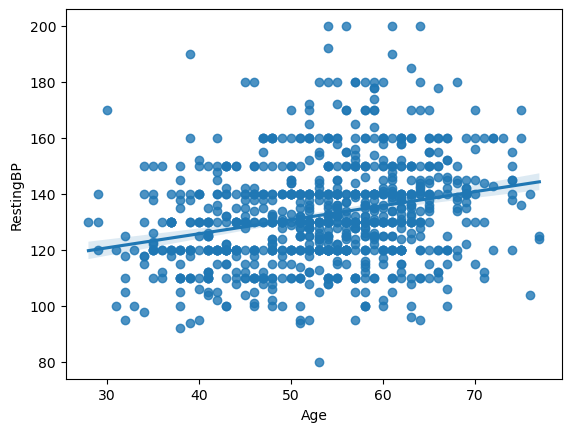

In [33]:
sns.regplot(x='Age', y='RestingBP', data=df)

<Axes: >

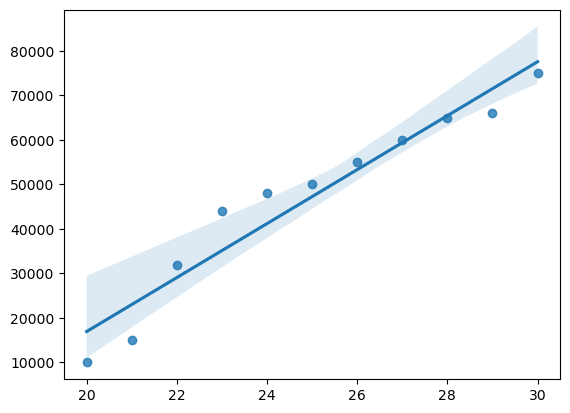

In [34]:
x = [20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
y = [10000, 15000, 32000, 44000, 48000, 50000, 55000, 60000, 65000, 66000, 75000]
sns.regplot(x=x, y=y)

<Axes: >

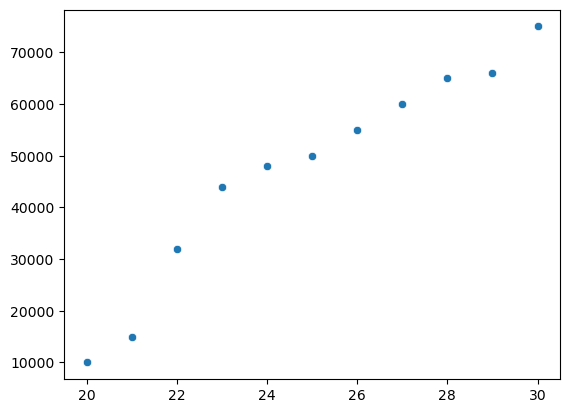

In [35]:
sns.scatterplot(x=x, y=y)

In [36]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414885,0.834754,0,1.382928,-0.727592,0,1,0,1,0,0,0,1,0,1,0,0,0,1
1,-0.478484,1.527224,-1.210675,0,0.754157,0.282891,1,0,0,0,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141284,0.722161,0,-1.525138,-0.727592,0,1,0,1,0,0,0,0,1,1,0,0,0,1
3,-0.584556,0.303651,-0.572651,0,-1.132156,0.282891,1,0,1,0,0,0,0,1,0,0,1,0,1,0
4,0.051881,0.971054,-0.929194,0,-0.581981,-0.727592,0,1,0,0,1,0,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,-0.902775,-1.253622,0.365619,0,-0.188999,0.282891,1,1,0,0,0,1,0,1,0,1,0,0,1,0
914,1.536902,0.637353,-0.966725,1,0.164684,2.303858,1,1,1,0,0,0,0,1,0,1,0,0,1,0
915,0.370100,-0.141284,-2.130180,0,-0.857069,0.282891,1,1,1,0,0,0,0,1,0,0,1,0,1,0
916,0.370100,-0.141284,-0.159813,0,1.461525,-0.727592,1,0,0,1,0,0,1,0,0,1,0,0,1,0


In [37]:
df_encode.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA',
       'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH',
       'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N',
       'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [39]:
x = df_encode.drop('HeartDisease', axis=1)
y = df_encode['HeartDisease']

In [40]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [69]:
models = {
    '_logistic_regression' : LogisticRegression(),
    '_KNN' : KNeighborsClassifier(n_neighbors=20),
    '_Naive_Bayes' : GaussianNB(),
    '_Decision_Tree' : DecisionTreeClassifier(),
    '_Support_Vector_Machine' : SVC()
}

In [70]:
def train(model_name):
    model = models[model_name]
    model.fit(x_train, y_train)
    acc = (accuracy_score(y_test, model.predict(x_test)).__round__(4)*100)
    print(f'====================== ANALYSIS OF MODEL {model_name} ======================')
    print(f'Accuracy of model {model_name} :', acc, '%')
    print(f'F1 score of model {model_name} :', f1_score(y_test, model.predict(x_test)).__round__(4)*100, '%')
    print(f'Confusion matrix of model {model_name} -')
    print(confusion_matrix(y_test, model.predict(x_test)))
    print(f'Classification Report of model {model_name} -')
    print(classification_report(y_test, model.predict(x_test)))
    print('=============================================================================\n')

In [71]:
for i in models:
    train(i)

====================== ANALYSIS OF MODEL _logistic_regression ======================
Accuracy of model _logistic_regression : 86.41 %
F1 score of model _logistic_regression : 87.92 %
Confusion matrix of model _logistic_regression -
[[68  9]
 [16 91]]
Classification Report of model _logistic_regression -
              precision    recall  f1-score   support

           0       0.81      0.88      0.84        77
           1       0.91      0.85      0.88       107

    accuracy                           0.86       184
   macro avg       0.86      0.87      0.86       184
weighted avg       0.87      0.86      0.86       184


====================== ANALYSIS OF MODEL _KNN ======================
Accuracy of model _KNN : 84.78 %
F1 score of model _KNN : 86.27 %
Confusion matrix of model _KNN -
[[68  9]
 [19 88]]
Classification Report of model _KNN -
              precision    recall  f1-score   support

           0       0.78      0.88      0.83        77
           1       0.91      0.82

In [72]:
import joblib
joblib.dump(models['_logistic_regression'], '_logistic_regression_hearts.pkl')
joblib.dump(scalar, 'scalar.pkl')
joblib.dump(x.columns.tolist(), 'columns.pkl')

['columns.pkl']